<a href="https://colab.research.google.com/github/dhruvbit/Machine-project/blob/main/quality_access_of_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install directory_tree


In [2]:
import os
import sys

import matplotlib.pyplot as plt
from directory_tree import DisplayTree
from fastai.vision.all import show_image, show_titled_image
from tqdm.auto import tqdm


def get_dataloader_bar(dataloader, color="green"):
    """
    Creates and configures a progress bar for a given dataloader.

    Args:
        dataloader (torch.utils.data.DataLoader): The dataloader providing the dataset.
        color (str): The color of the progress bar.

    Returns:
        pbar (tqdm.tqdm): The configured progress bar object.
    """
    # Get the total number of samples from the dataloader's dataset.
    num_samples = len(dataloader.dataset)

    # Initialize a tqdm progress bar with specified settings.
    pbar = tqdm(
        # Set the total number of iterations for the bar.
        total=num_samples,
        # Dynamically calculate the width of the progress bar.
        ncols=int(num_samples / 10) + 300,
        # Define the format string for the progress bar's appearance.
        bar_format="{desc} {bar} {postfix}",
        # Direct the progress bar output to the standard output stream.
        file=sys.stdout,
        # Set the color of the progress bar.
        colour=color,
    )

    # Return the configured progress bar object.
    return pbar



def update_dataloader_bar(p_bar, batch, current_bs, n_samples):
    """
    Updates the existing progress bar with the current batch information.

    Args:
        p_bar (tqdm.tqdm): The progress bar object to update.
        batch (int): The current batch index.
        current_bs (int): The size of the current batch.
        n_samples (int): The total number of samples in the dataset.
    """
    # Advance the progress bar by the number of items in the current batch.
    p_bar.update(current_bs)
    # Set the description to show the current batch number.
    p_bar.set_description(f"Batch {batch+1}")

    # Check if the current batch is the last one.
    if (batch + 1) * current_bs > n_samples:
        # Update the postfix to show the total number of samples processed.
        p_bar.set_postfix_str(f"{n_samples} of a total of  {n_samples} samples")
    else:
        # Update the postfix to show the cumulative number of samples processed.
        p_bar.set_postfix_str(
            f"{current_bs*(batch+1)} of a total of  {n_samples} samples"
        )



def plot_img(img, label=None, info=None, ax=None):
    """
    Plots an image with optional labels and supplementary information.

    Args:
        img (torch.Tensor or numpy.ndarray): The image data to plot.
        label (str): Optional label to display as the title.
        info (str): Optional supplementary text to display below the image.
        ax (matplotlib.axes.Axes): Optional matplotlib axes to plot on.
    """
    def add_info_text(ax, info):
        """
        Adds supplementary text below the plot on a given axes.

        Args:
            ax (matplotlib.axes.Axes): The matplotlib axes object.
            info (str): The text to be added.
        """
        # Add text to the axes at a specified position.
        ax.text(
            0.5, -0.1, info, transform=ax.transAxes, ha="center", va="top", fontsize=10
        )
        # Set the x-axis label position to the top.
        ax.xaxis.set_label_position("top")

    # Create a new figure and axes if none are provided.
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Check if a label is provided to determine how to display the image.
    if label:
        # Create a title string with the provided label.
        title = f"Label: {label}"
        # Display the image with the generated title.
        show_titled_image((img, title), ax=ax)
    else:
        # Display the image without a title.
        show_image(img, ax=ax)

    # Check if supplementary information is provided.
    if info:
        # Add the information as text below the image.
        add_info_text(ax, info)

    # If no axes were passed in, display the newly created plot.
    if ax is None:
        plt.show()



def get_grid(num_rows, num_cols, figsize=(16, 8)):
    """
    Creates a grid of subplots and ensures the axes object is consistently formatted.

    Args:
        num_rows (int): The number of rows in the subplot grid.
        num_cols (int): The number of columns in the subplot grid.
        figsize (tuple): The dimensions of the overall figure.

    Returns:
        fig (matplotlib.figure.Figure): The generated matplotlib figure object.
        axes (list): The formatted axes grid, structured as an iterable or 2D list.
    """
    # Create a figure and a set of subplots.
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    # Handle the case where there is only one row.
    if num_rows == 1:
        # Ensure the axes object is iterable for consistency.
        axes = [axes]
    # Handle the case where there is only one column.
    elif num_cols == 1:
        # Ensure the axes object is a 2D list for consistent indexing.
        axes = [[ax] for ax in axes]

    # Return the figure and the formatted axes grid.
    return fig, axes



def print_data_folder_structure(root_dir, max_depth=1):
    """
    Prints the directory tree structure for a given root directory.

    Args:
        root_dir (str): The starting path for the directory tree.
        max_depth (int): The maximum depth for the tree traversal.
    """
    # Define the configuration settings for displaying the directory tree.
    config_tree = {
        # Specify the starting path for the directory tree.
        "dirPath": root_dir,
        # Set to False to include both files and directories.
        "onlyDirs": False,
        # Set the maximum depth for the tree traversal.
        "maxDepth": max_depth,
        # Specify a sorting option (100 typically means no specific sort).
        "sortBy": 100,
    }
    # Create and display the tree structure using the unpacked configuration.
    DisplayTree(**config_tree)


def explore_extensions(root_dir):
    """
    Explores a directory tree to group all file paths by their file extensions.

    Args:
        root_dir (str): The starting directory path to search.

    Returns:
        extensions (dict): A dictionary mapping file extensions to a list of matching file paths.
    """
    # Initialize a dictionary to store file paths, grouped by extension.
    extensions = {}
    # Walk through the directory tree starting from the root directory.
    for dirpath, _, filenames in os.walk(root_dir):
        # Iterate over each file in the current directory.
        for filename in filenames:
            # Extract the file extension and convert it to lowercase.
            ext = os.path.splitext(filename)[1].lower()
            # If the extension has not been seen before, add it to the dictionary.
            if ext not in extensions:
                # Initialize a new list for this extension.
                extensions[ext] = []
            # Append the full path of the file to the list for its extension.
            extensions[ext].append(os.path.join(dirpath, filename))
    # Return the dictionary of extensions and their corresponding file paths.
    return extensions



def quick_debug(img):
    """
    Prints basic debugging information about an image tensor.

    Args:
        img (torch.Tensor): The image tensor to inspect.
    """
    # Print the shape of the image tensor.
    print(f"Shape: {img.shape}")  # Should be [3, 224, 224]
    # Print the data type of the tensor.
    print(f"Type: {img.dtype}")  # Should be torch.float32
    # Print the minimum and maximum pixel values in the tensor.
    print(
        f"Range of pixel values: [{img.min():.1f}, {img.max():.1f}]"
    )

In [3]:
import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import requests
import scipy
from PIL import Image  #??
from torch.utils.data import Dataset,Subset,random_split,DataLoader #??
from torchvision import transforms
from tqdm.auto import tqdm #???




In [4]:
def download_dataset():
    """
    Downloads and extracts a dataset from remote URLs if not already present locally.

    This function first checks for the existence of the dataset files in a specific
    directory. If the files are not found, it proceeds to download them from
    pre-defined URLs, and then extracts the contents.
    """
    # Define the directory to store the dataset.
    data_dir = "flower_data"

    # Define paths for key files and folders.
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    # Check if the primary data folder and a key label file already exist.
    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        # Inform the user that the dataset is already available locally.
        print(f"Dataset already exists. Loading locally from '{data_dir}'.")
        # Exit the function since no download is needed.
        return

    # Inform the user that the dataset is not found and the download will start.
    print("Dataset not found locally. Downloading...")

    # Define the URLs for the image archive and the labels file.
    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    # Create the target directory for the dataset, if it doesn't already exist.
    os.makedirs(data_dir, exist_ok=True)

    # Announce the start of the image download process.
    print("Downloading images...")
    # Send an HTTP GET request to the image URL, enabling streaming for large files.
    response = requests.get(image_url, stream=True)
    # Get the total size of the file from the response headers for the progress bar.
    total_size = int(response.headers.get("content-length", 0))

    # Open a local file in binary write mode to save the downloaded archive.
    with open(tgz_path, "wb") as file:
        # Iterate over the response content in chunks with a progress bar.
        for data in tqdm(
            # Define the chunk size for iterating over the content.
            response.iter_content(chunk_size=1024),
            # Set the total for the progress bar based on the file size in kilobytes.
            total=total_size // 1024,
        ):
            # Write each chunk of data to the file.
            file.write(data)

    # Announce the start of the file extraction process.
    print("Extracting files...")
    # Open the downloaded tar.gz archive in read mode.
    with tarfile.open(tgz_path, "r:gz") as tar:
        # Extract all contents of the archive into the target directory.
        tar.extractall(data_dir)

    # Announce the start of the labels download process.
    print("Downloading labels...")
    # Send an HTTP GET request to the labels URL.
    response = requests.get(labels_url)
    # Open a local file in binary write mode to save the labels.
    with open(labels_file_path, "wb") as file:
        # Write the entire content of the response to the file.
        file.write(response.content)

    # Inform the user that the download and extraction are complete.
    print(f"Dataset downloaded and extracted to '{data_dir}'.")

    # create labels_description.txt
    labels_description = [
        'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily',
        'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea',
        'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
        'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
        'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation',
        'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
        'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
        'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia',
        'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
        'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy',
        'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
        'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
        'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 'watercress',
        'canna lily', 'hippeastrum ', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
        'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
    ]

    with open(os.path.join(data_dir, "labels_description.txt"), "w") as f:
        for idx, label in enumerate(labels_description, start=1):
            f.write(f"{label}\n")

In [5]:
download_dataset()

Dataset not found locally. Downloading...


  0%|          | 0/336779 [00:00<?, ?it/s]

Extracting files...


/tmp/ipykernel_2550/4151110232.py:58: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


Dataset downloaded and extracted to 'flower_data'.


In [6]:
path_dataset = './flower_data'

print_data_folder_structure(path_dataset, max_depth=1)

flower_data/
├── 102flowers.tgz
├── imagelabels.mat
├── jpg/
└── labels_description.txt


In [30]:
class FlowerDataset(Dataset):
    """
    A custom dataset class for loading image data.

    This class is designed to work with PyTorch's Dataset and DataLoader
    abstractions. It handles loading images and their corresponding labels
    from a specific directory structure.
    """
    def __init__(self, root_dir, transform=None):
        """
        Initializes the dataset object.

        Args:
            root_dir (str): The root directory where the dataset is stored.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        # Store the root directory path.
        self.root_dir = root_dir
        # Store the optional transformations.
        self.transform = transform
        # Construct the full path to the image directory.
        self.image_dir = os.path.join(self.root_dir, "jpg")
        # Load and process the labels from the corresponding file.
        self.labels = self.load_and_correct_labels()

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        Returns:
            total_samples (int): The total number of items in the dataset.
        """
        # The total number of samples is the number of labels.
        total_samples = len(self.labels)
        # Return the total number of samples.
        return total_samples

    def __getitem__(self, idx):
        """
        Retrieves a sample from the dataset at the specified index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (PIL.Image.Image or torch.Tensor): The processed image data.
            label (int): The corresponding label for the image.
        """
        # Retrieve the image for the given index.
        image = self.retrieve_image(idx)

        # Check if a transform is provided.
        if self.transform is not None:
            # Apply the transform to the image.
            image = self.transform(image)

        # Get the label corresponding to the index.
        label = self.labels[idx]

        # Return the processed image and its label.
        return image, label

    def retrieve_image(self, idx):
        """
        Loads a single image from disk based on its index.

        Args:
            idx (int): The index of the image to load.

        Returns:
            image (PIL.Image.Image): The loaded image, converted to RGB.
        """
        # Construct the image filename based on the index.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.image_dir, img_name)
        # Open the image file.
        with Image.open(img_path) as img:
            # Convert the image to the RGB color space.
            image = img.convert("RGB")
        # Return the converted image.
        return image

    def load_and_correct_labels(self):
        """
        Loads labels from a file and adjusts them to be zero-indexed.

        Returns:
            labels (numpy.ndarray): An array of zero-indexed integer labels.
        """
        # Load the file containing the labels.
        self.labels_mat = scipy.io.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extract the labels array and correct for zero-based indexing.
        labels = self.labels_mat["labels"][0] - 1
        # Return the processed labels.
        return labels

    def get_label_description(self, label):
        """
        Retrieves the text description for a given label index.

        Args:
            label (int): The integer label.

        Returns:
            description (str): The corresponding text description of the label.
        """
        # Construct the path to the file containing label descriptions.
        path_labels_description = os.path.join(self.root_dir, "labels_description.txt")
        # Open the label description file for reading.
        with open(path_labels_description, "r") as f:
            # Read all lines from the file.
            lines = f.readlines()
        # Get the description for the specified label and remove leading/trailing whitespace.
        description = lines[label].strip()
        # Return the clean description.
        return description






In [25]:
# Initialize the dataset object, providing the path to the data.
dataset = FlowerDataset(path_dataset)

In [26]:
print(f"numebr of sample int the datset{len(dataset)}")

numebr of sample int the datset8189


In [27]:
sel_idx = 10
img,label = dataset[sel_idx]

In [28]:
img_size_info = f"Image size: {img.size}"

# Print the image size information along with its corresponding label.
print(f'{img_size_info}, Label: {label}')

Image size: (500, 748), Label: 76


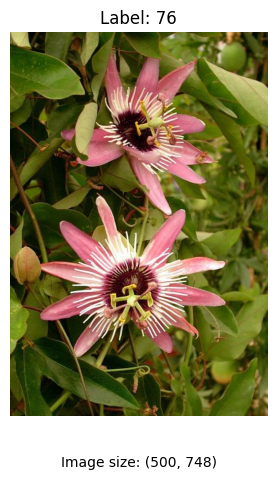

In [31]:
plot_img(img, label=label, info=img_size_info)

In [32]:
dataset_labels = dataset.labels

# Create a set of unique labels to remove duplicates.
unique_labels = set(dataset_labels) #used set becoz it cant handle duplicates

# Iterate through each unique label.
for label in unique_labels:
    # Print the numerical label and its corresponding text description.
    print(f'Label: {label}, Description: {dataset.get_label_description(label)}')

Label: 0, Description: pink primrose
Label: 1, Description: hard-leaved pocket orchid
Label: 2, Description: canterbury bells
Label: 3, Description: sweet pea
Label: 4, Description: english marigold
Label: 5, Description: tiger lily
Label: 6, Description: moon orchid
Label: 7, Description: bird of paradise
Label: 8, Description: monkshood
Label: 9, Description: globe thistle
Label: 10, Description: snapdragon
Label: 11, Description: colt's foot
Label: 12, Description: king protea
Label: 13, Description: spear thistle
Label: 14, Description: yellow iris
Label: 15, Description: globe-flower
Label: 16, Description: purple coneflower
Label: 17, Description: peruvian lily
Label: 18, Description: balloon flower
Label: 19, Description: giant white arum lily
Label: 20, Description: fire lily
Label: 21, Description: pincushion flower
Label: 22, Description: fritillary
Label: 23, Description: red ginger
Label: 24, Description: grape hyacinth
Label: 25, Description: corn poppy
Label: 26, Descript

In [36]:
def visual_exploration(dataset, num_rows=2, num_cols=4):
    """
    Displays a grid of randomly selected samples from a dataset for visual inspection.

    Args:
        dataset (Dataset): The dataset object from which to draw samples. It should support
            indexing and have a `get_label_description` method.
        num_rows (int): The number of rows in the display grid.
        num_cols (int): The number of columns in the display grid.
    """
    # Calculate the total number of images to display in the grid.
    total_samples = num_rows * num_cols

    # Select a random set of unique indices from the dataset.
    indices = np.random.choice(len(dataset), total_samples, replace=False)

    # Create a grid of subplots to hold the images.
    fig, axes = get_grid(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 4))

    # Iterate over each subplot axis and the corresponding random sample index.
    for ax, idx in zip(axes.flatten(), indices):
        # Retrieve the image and its numerical label from the dataset.
        image, label = dataset[idx]

        # Get the human-readable text description for the label.
        description = dataset.get_label_description(label)

        # Format a new label string that includes both the number and description.
        label = f"{label} - {description}"

        # Create an information string with the sample's index and image dimensions.
        info = f"Index: {idx} Size: {image.size}"

        # Plot the image on the current subplot with its label and info.
        plot_img(image, label=label, info=info, ax=ax)

    # Render and display the entire grid of images.
    plt.show()

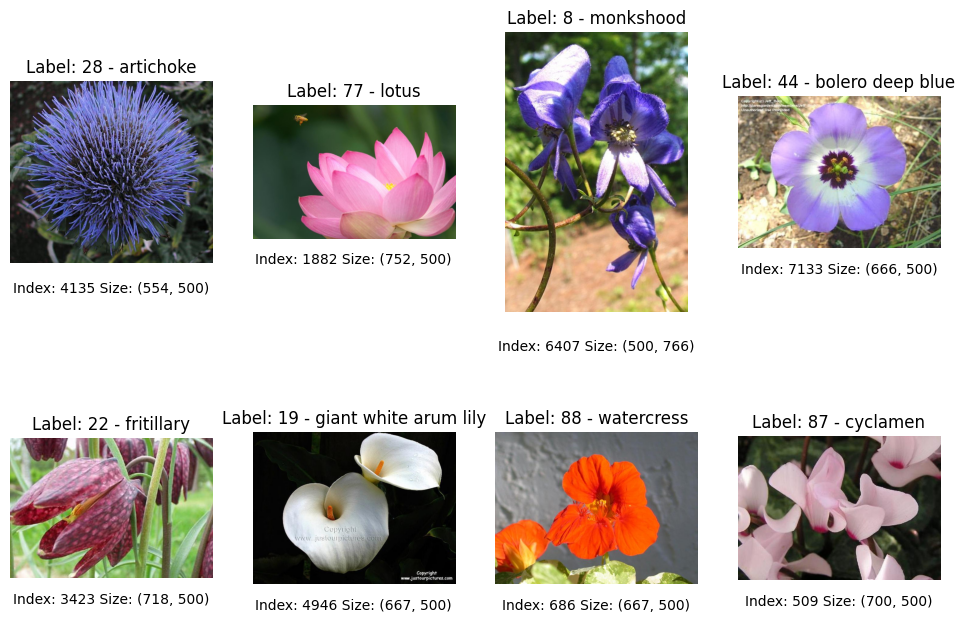

In [37]:
visual_exploration(dataset, num_rows=2, num_cols=4)

In [41]:
mean = [0.485, 0.456, 0.406]
# Define the standard deviation values for normalization.
std = [0.229, 0.224, 0.225]

In [42]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,std=std),
])

In [43]:
dataset_transformed = FlowerDataset(path_dataset,transform=transform)

Shape: torch.Size([3, 224, 224])
Type: torch.float32
Range of pixel values: [-2.1, 2.6]


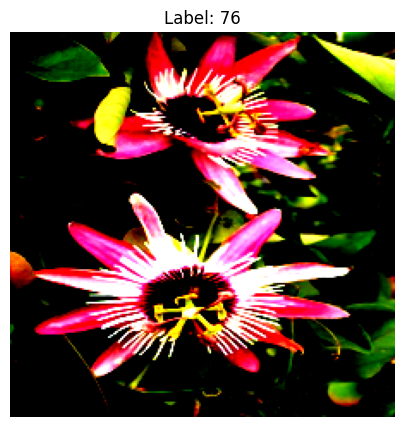

In [44]:
img_transformed, label = dataset_transformed[sel_idx]

# quick check
quick_debug(img_transformed)

# Plot the transformed image
plot_img(img_transformed, label=label)